## **1. Dataset Selection and Exploration**
We are using the **Banknote Authentication Dataset** from the UCI Machine Learning Repository. This dataset contains features extracted from images of banknotes and is used for a binary classification task: authentic vs. forged notes.

### **Features:**
- **Variance of Wavelet Transformed Image**
- **Skewness of Wavelet Transformed Image**
- **Curtosis of Wavelet Transformed Image**
- **Entropy of Image**

### **Target Variable:**
- **1** → Authentic Banknote  
- **0** → Forged Banknote  

### **Initial Exploration**
We explored the dataset by:
- Checking the number of samples and features.
- Displaying the first few rows.
- Checking for missing values.
- Plotting class distributions to confirm balanced data.
- Visualizing feature distributions using Pairplot.

---

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [37]:
# Define column names
columns = ["Variance", "Skewness", "Kurtosis", "Entropy", "Label"]

# Read the CSV file
df = pd.read_csv('data_banknote_authentication.txt', names=columns)

# Display the first few rows
df.head()

,Variance,Skewness,Kurtosis,Entropy,Label
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [38]:
# Check for missing values
print(df.isnull().sum())

Variance    0
Skewness    0
Kurtosis    0
Entropy     0
Label       0
dtype: int64


In [39]:
# Check class distribution
print(df["Label"].value_counts())

0    762
1    610
Name: Label, dtype: int64


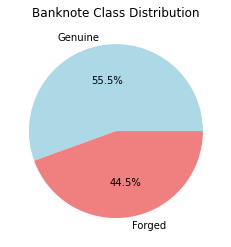

In [41]:
# Plot class distribution
df["Label"].value_counts().plot(kind="pie", autopct="%1.1f%%", labels=["Genuine", "Forged"], colors=["lightblue", "lightcoral"])
plt.title("Banknote Class Distribution")
plt.ylabel("")  # Hide y-label
plt.show()

In [40]:
df.describe()

,Variance,Skewness,Kurtosis,Entropy,Label
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


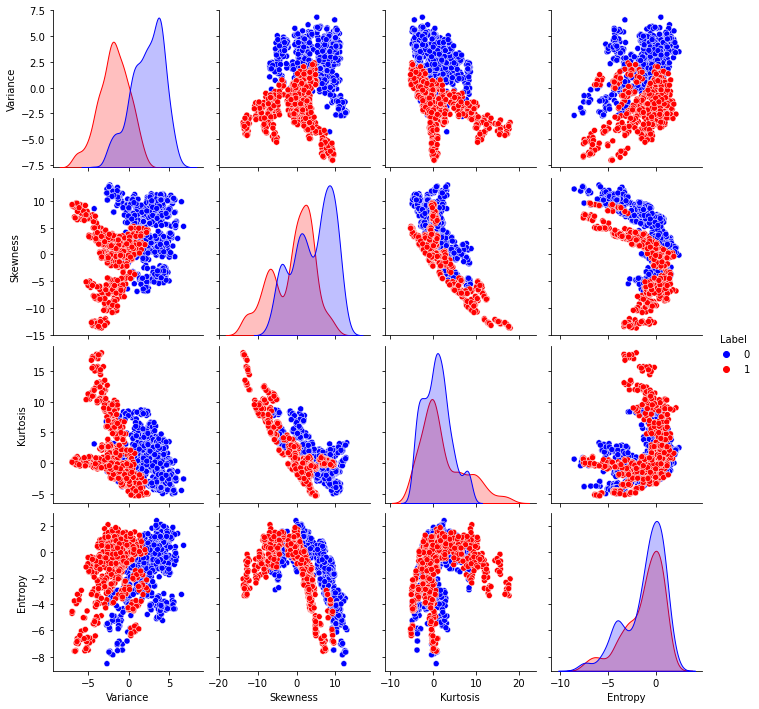

In [42]:
# Pairplot for feature distribution and class separation
sns.pairplot(df, hue="Label", diag_kind="kde", palette=["blue", "red"])
plt.show()

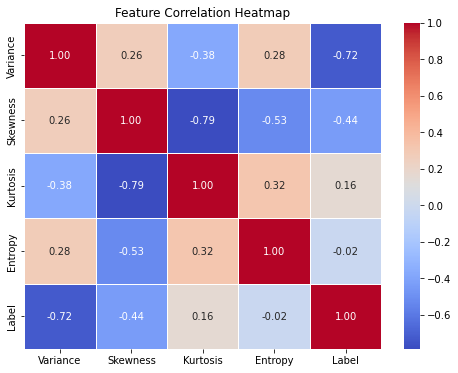

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


## **2. Splitting Data into Train and Test Sets**
We split the dataset into **80% training data** and **20% test data** using `train_test_split` from `sklearn.model_selection`. This ensures our model is trained on a large portion of the data while keeping a separate test set for evaluation.

---

In [44]:
# Separate features (X) and labels (y)
X = df.drop(columns=["Label"])  # Features: Variance, Skewness, Kurtosis, Entropy
y = df["Label"]  # Target: Genuine (0) or Forged (1)

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the size of training and test sets
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 1097 samples
Test set size: 275 samples



## **3. Logistic Regression Model**
To establish a baseline, we trained a **Logistic Regression** model using `sklearn.linear_model.LogisticRegression`.  

### **Evaluation Metrics:**
We evaluated the model using:
- **Accuracy**
- **Precision**
- **Recall**
- **F1-Score**

The results showed that Logistic Regression performs well on this dataset, providing a benchmark for our neural network.

---

In [45]:
# Initialize logistic regression model
log_reg = LogisticRegression()

# Train the model on the training data
log_reg.fit(X_train, y_train)

LogisticRegression()

In [46]:
# Predict on the test set
y_pred = log_reg.predict(X_test)

# Compute accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Logistic Regression Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Print full classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Display Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

Logistic Regression Metrics:
Accuracy: 0.9855
Precision: 0.9683
Recall: 1.0000
F1 Score: 0.9839

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99       153
           1       0.97      1.00      0.98       122

    accuracy                           0.99       275
   macro avg       0.98      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275


Confusion Matrix:
[[149   4]
 [  0 122]]



## **4. Implementing a Neural Network from Scratch**
Instead of using `sklearn`, we implemented a simple **one-layer neural network** from scratch.

### **Architecture:**
- **Input Layer:** 4 neurons (one per feature)
- **Output Layer:** 1 neuron (binary classification)
- **Activation Function:** **Sigmoid**  
- **Loss Function:** **Binary Cross-Entropy**
- **Weight Initialization:** Small random values
- **Optimizer:** **Gradient Descent**
- **Learning Rate:** Tunable parameter
- **Epochs:** Trained until convergence

<img src="Sigmoid Activation Function.png">

In [47]:
# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

<img src="Binary Cross-Entropy Loss.png">

In [48]:
# Compute binary cross-entropy loss
def binary_cross_entropy(y_true, y_pred):
    m = y_true.shape[0]
    loss = -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))
    return loss

<img src="Initialize Weights and Bias.png">

In [49]:
def initialize_weights(n_features):
    W = np.random.randn(n_features, 1) * 0.01  # Ensure W has shape (n_features, 1)
    b = 0
    return W, b

<img src="Forward Propagation.png">

In [50]:
def forward_propagation(X, W, b):
    Z = np.dot(X, W) + b  # Now W has the correct shape
    A = sigmoid(Z)
    return A

<img src="Backpropagation (Gradient Descent).png">

In [51]:
def backward_propagation(X, y, A, W, b, learning_rate):
    m = X.shape[0]  # Number of samples
    
    dW = (1/m) * np.dot(X.T, (A - y))  # Ensure proper shapes
    db = (1/m) * np.sum(A - y)
    
    W -= learning_rate * dW
    b -= learning_rate * db
    
    return W, b

### **4.5 Training Loop**
- Iterate over multiple epochs.
- Perform forward propagation.
- Compute loss.
- Perform backpropagation.
- Update weights.

In [52]:
# Train the neural network
def train_neural_network(X_train, y_train, epochs=1000, learning_rate=0.01):
    n_features = X_train.shape[1]
    W, b = initialize_weights(n_features)  # Initialize parameters
    
    for epoch in range(epochs):
        # Forward pass
        A = forward_propagation(X_train, W, b)
        
        # Compute loss
        loss = binary_cross_entropy(y_train, A)
        
        # Backward pass (update weights)
        W, b = backward_propagation(X_train, y_train, A, W, b, learning_rate)
        
        # Print loss every 100 epochs
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Loss = {loss:.4f}")
    
    return W, b

## 4.6 Training the Model

In [53]:
# Convert pandas dataframe to numpy arrays
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy().reshape(-1, 1)  # Reshape to match expected dimensions

# Train the model
W_final, b_final = train_neural_network(X_train_np, y_train_np, epochs=1000, learning_rate=0.01)

Epoch 0: Loss = 0.6881
Epoch 100: Loss = 0.2641
Epoch 200: Loss = 0.2001
Epoch 300: Loss = 0.1701
Epoch 400: Loss = 0.1514
Epoch 500: Loss = 0.1382
Epoch 600: Loss = 0.1281
Epoch 700: Loss = 0.1200
Epoch 800: Loss = 0.1133
Epoch 900: Loss = 0.1076


## 4.7 Model Evaluation

In [54]:
# Make predictions on test data
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy().reshape(-1, 1)

# Forward pass to get predictions
y_pred_prob = forward_propagation(X_test_np, W_final, b_final)

# Convert probabilities to binary labels (Threshold = 0.5)
y_pred_labels = (y_pred_prob >= 0.5).astype(int)

# Compute accuracy
nn_accuracy = accuracy_score(y_test_np, y_pred_labels)

print(f"Neural Network Test Accuracy: {nn_accuracy:.4f}")

Neural Network Test Accuracy: 0.9745


## Step 4.8: Compare with Logistic Regression
After training, we evaluated the neural network using the same metrics as Logistic Regression (**Accuracy**) and compared the performance.

In [55]:
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"Neural Network Accuracy: {nn_accuracy:.4f}")

Logistic Regression Accuracy: 0.9855
Neural Network Accuracy: 0.9745


## 5. Neural Networks and Self-Learning: The Coffee-Making Intern  

### Step 1: First Attempt (Initial Prediction)  
You hire a new intern, **Alex**, who has never made coffee before.  
Without instructions, Alex **guesses** the best way to make coffee.  
- Maybe they add too many beans, too little water, or brew it for too long.  

### Step 2: Taste Test (Error Calculation)  
You take a sip and realize the coffee is **too bitter**.  
You give feedback:  
> “This isn’t quite right. It needs less coffee and more water.”  
This is like the **loss function** in a neural network, which measures how far the prediction (the coffee) is from the correct answer (a perfect cup).  

### Step 3: Learning from Mistakes (Backpropagation)  
Alex takes your feedback and **traces back** their steps to see what went wrong.  
- They tweak the coffee-to-water ratio slightly to improve the taste.  
This is similar to **backpropagation**, where the neural network looks at its mistakes and **adjusts** the internal weights accordingly.  

### Step 4: Multiple Attempts (Training Process)  
Alex keeps trying—each time making **small improvements**.  
- With each new cup, they get feedback and refine their method.  
- Over time, Alex figures out the **perfect balance** without needing further guidance.  
This is like a neural network **training** on data, slowly improving accuracy with every iteration.  

### Step 5: Mastery (Trained Model)  
After many tries, Alex **no longer needs your help**—they now know how to make the perfect cup of coffee every time.  
The neural network works the same way: after enough training, it can classify new data accurately on its own, without additional corrections.  

---

### How This Relates to AI & Business  
Just like Alex, a neural network **learns from experience**—not by memorizing rules but by improving through **trial and error**.  
That’s why we call it **self-learning**—it figures out patterns and improves its performance without needing explicit instructions.  
